1. DBSCAN (Density-Based Clustering)
2. Gaussian Mixture Model (GMM)
3. Comparative Study of Clustering Algorithms

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [2]:
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


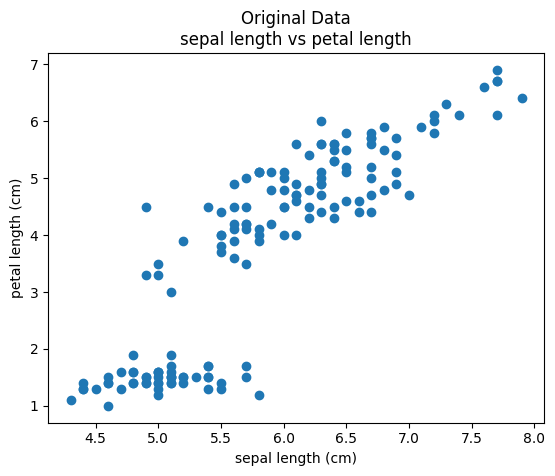

In [5]:
plt.figure()
plt.scatter(X['sepal length (cm)'], X['petal length (cm)'])
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.title('Original Data\nsepal length vs petal length')
plt.show()

Part 1: K-Means Clustering (Baseline)

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)
kmeans_score = silhouette_score(X, kmeans_labels)
print("K-Means Silhouette Score: {:.4f}".format(kmeans_score))

K-Means Silhouette Score: 0.5512


0      5.1
1      4.9
2      4.7
3      4.6
4      5.0
      ... 
145    6.7
146    6.3
147    6.5
148    6.2
149    5.9
Name: sepal length (cm), Length: 150, dtype: float64
0      1.4
1      1.4
2      1.3
3      1.5
4      1.4
      ... 
145    5.2
146    5.0
147    5.2
148    5.4
149    5.1
Name: petal length (cm), Length: 150, dtype: float64


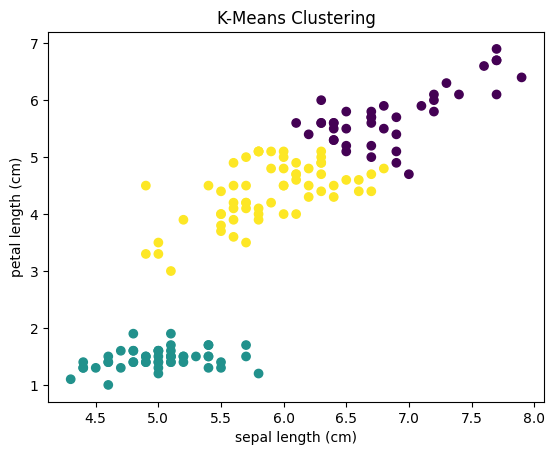

In [13]:
plt.figure()
plt.scatter(X.iloc[:,0], X.iloc[:,2], c = kmeans_labels)
print(X.iloc[:,0])
print(X.iloc[:,2])
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.title("K-Means Clustering")
plt.show()

Part 2: DBSCAN Clustering

In [15]:
dbscan = DBSCAN(eps=0.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X)

# Remove noise (-1) before silhouette
if len(set(dbscan_labels)) > 1:
    dbscan_score = silhouette_score(X, dbscan_labels)
else:
    dbscan_score = -1

print("DBSCAN Silhouette Score:", dbscan_score)

DBSCAN Silhouette Score: 0.48603419703456857


In [16]:
dbscan = DBSCAN(eps=0.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X)

# Remove noise (-1) before silhouette
if len(set(dbscan_labels)) > 1:
    dbscan_score = silhouette_score(X, dbscan_labels)
else:
    dbscan_score = -1

print("DBSCAN Silhouette Score:", dbscan_score)

DBSCAN Silhouette Score: 0.48603419703456857


Part 3: Gaussian Mixture Model (GMM)

In [18]:
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X)
gmm_score = silhouette_score(X, gmm_labels)
print("GMM Silhouette Score: {:.4f}".format(gmm_score))

GMM Silhouette Score: 0.5012


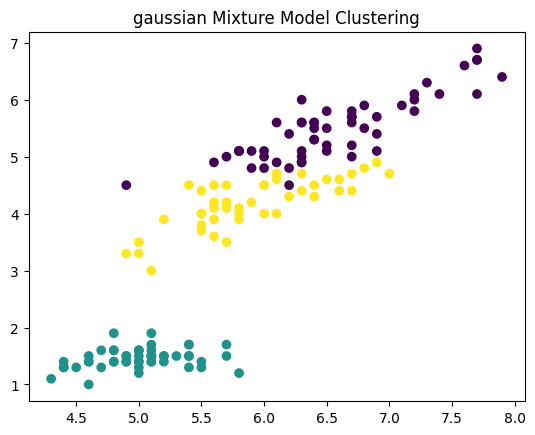

In [19]:
plt.figure()
plt.scatter(X.iloc[:,0], X.iloc[:,2], c = gmm_labels)
plt.title("Gaussian Mixture Model Clustering")
plt.show()

Compare All Algorithms

In [20]:
results = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN", "GMM"],
    "Silhouette Score": [kmeans_score, dbscan_score, gmm_score]
})

results

,Algorithm,Silhouette Score
0,K-Means,0.551192
1,DBSCAN,0.486034
2,GMM,0.501176


Visual Comparison

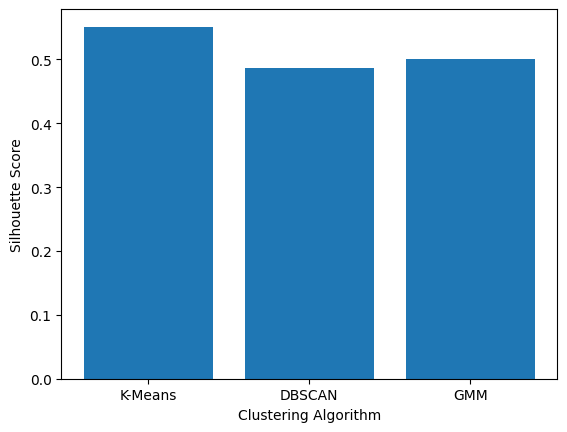

In [21]:
plt.figure()
plt.bar(results["Algorithm"], results["Silhouette Score"])
plt.xlabel("Clustering Algorithm")
plt.ylabel("Silhouette Score")
plt.show()